# Klassifikation

In diesem Notebook beschäftigen wir uns mit der Klassifikation von Daten. Wie in der letzten Übung werden Sie dazu Pandas und Scikit-learn verwenden. Zudem werden Sie einen Forward pass durch ein einfaches Neuronales Netz implementieren, und somit die Funktionsweise eines Neuronalen Netzes verstehen.


Wir beginnen mit dem import der benötigten Bibliotheken. 

In [239]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Aufgabe 1: Klassifikation von Tumoren 

In der ersten Aufgabe beschäftigen wir uns mit der Klassifikation von Tumoren. Wir verwenden dazu den *breast_cancer* Datensatz. Dieser Datensatz enthält Informationen über verschiedene Tumoren, und die Aufgabe besteht darin, zu entscheiden, ob ein Tumor gutartig oder bösartig ist.

Laden Sie den Datensatz `cancer.csv` (im Verzeichnise `Data_1`). Wenn Sie `df.head()` ausführen, erhalten Sie:

```text
   radius_mean  texture_mean  ...  fractal_dimension_worst  diagnosis
0        13.74         17.91  ...                  0.07014          0
1        13.37         16.39  ...                  0.07628          0
2        14.69         13.98  ...                  0.09208          0
3        12.91         16.33  ...                  0.06949          0
4        13.62         23.23  ...                  0.06953          0
```

Jede Zeile stellt eine Zelle dar. Die letzte Spalte (`diagnosis`) ist 1, wenn die Zelle krebsartig ist, und 0 falls diese gutartig ist. Alle anderen Spalten beschreiben geometrische Merkmale der Zelle. 

In [240]:

# Laden der Daten
df = pd.read_csv('Data_1/cancer.csv')
df.head()  # Zeigen Sie die ersten Zeilen des Dataframes an

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,13.74,17.91,88.12,585.0,0.07944,0.06376,0.02881,0.01329,0.1473,0.05580,...,22.46,97.19,725.9,0.09711,0.1824,0.1564,0.06019,0.2350,0.07014,0
1,13.37,16.39,86.10,553.5,0.07115,0.07325,0.08092,0.02800,0.1422,0.05823,...,22.75,91.99,632.1,0.10250,0.2531,0.3308,0.08978,0.2048,0.07628,0
2,14.69,13.98,98.22,656.1,0.10310,0.18360,0.14500,0.06300,0.2086,0.07406,...,18.34,114.10,809.2,0.13120,0.3635,0.3219,0.11080,0.2827,0.09208,0
3,12.91,16.33,82.53,516.4,0.07941,0.05366,0.03873,0.02377,0.1829,0.05667,...,22.00,90.81,600.6,0.10970,0.1506,0.1764,0.08235,0.3024,0.06949,0
4,13.62,23.23,87.19,573.2,0.09246,0.06747,0.02974,0.02443,0.1664,0.05801,...,29.09,97.58,729.8,0.12160,0.1517,0.1049,0.07174,0.2642,0.06953,0


Erstellen Sie wieder zwei Dataframes `X` und `y`, wobei `y` nur die Diagnosen enthalten und `X` alle anderen Spalten. Teilen Sie die Daten wieder in eine Trainings und ein Testset auf. Verwenden Sie 30 Prozent der Daten für das Testset und den Rest für das Trainingsset.

Skaliere die Daten mit einem `StandardScaler` 

In [241]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns = ["diagnosis"])
y = df["diagnosis"]

# Daten Aufteilen in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)

# Daten skalieren

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistische Regression

Nutzen Sie eine [Logistische Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) und machen Sie eine Vorhersage auf den Daten. Berechnen Sie die *Accuracy*, also die Anzahl korrekter Vorhersagen dividiert durch die Anzahl Vorhersagen. Diese steht Ihnen auch bereits vorgefertigt in scikit-learn als [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) zur Verfügung.

In [242]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Erstellen und anpassen des logistischen Regressionsmodells


lr = LogisticRegression() # Erstellen des Modells
lr.fit(X_train_scaled, y_train) # Anpassen des Modells an die Trainingsdaten

# Vorhersagegenauigkeit berechnen. 
accuracy_train = accuracy_score(y_train, lr.predict(X_train_scaled))
accuracy_test = accuracy_score(y_test, lr.predict(X_test_scaled))

print("Accuracy Trainingsdaten: ", accuracy_train)
print("Accuracy Testdaten: ", accuracy_test)


Accuracy Trainingsdaten:  0.9856115107913669
Accuracy Testdaten:  0.9916666666666667


### Trainieren eines Neuralen Netzes

Nun trainieren Sie ein einfaches Neuronales Netz. Dafür können Sie den [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) verwenden. Trainieren Sie das Netz auf den Trainingsdaten und berechnen Sie die Accuracy auf den Trainings- und Testdaten. Experimentieren Sie mit der Anzahl der Neuronen in den versteckten Schichten, um die Accuracy zu verbessern. Können Sie die Accuracy der Logistischen Regression übertreffen?

In [243]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=10000, random_state=42)
mlp.fit(X_train_scaled, y_train)

y_pred_train = mlp.predict(X_train_scaled)
y_pred_test = mlp.predict(X_test_scaled)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("Trainingsgenauigkeit: ", accuracy_train)
print("Testgenauigkeit: ", accuracy_test)

Trainingsgenauigkeit:  0.9892086330935251
Testgenauigkeit:  0.9916666666666667


Im letzten Aufgabenblatt haben Sie die gelernt, wie Sie die Hyperparameter mittels GridSearchCV optimieren können. Probieren Sie das auch hier aus, um die Hyperparameter des MLPClassifiers zu optimieren. Optimieren Sie die Anzahl der Neuronen in den versteckten Schichten, die Anzahl der versteckten Schichten, und die Activation (siehe [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) und [GridSearchCV-Dokumentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)).

Können Sie die Accuracy weiter verbessern?



In [244]:
from sklearn.model_selection import GridSearchCV

classifier = MLPClassifier(max_iter= 10000, random_state=42)
param_grid = {
    "hidden_layer_sizes": [(10,), (20,), (10, 10,), (20, 20,)],
    "activation": ["relu", "tanh"],
}

gs = GridSearchCV(classifier, param_grid=param_grid, refit=True, cv=4)
gs.fit(X_train_scaled, y_train)

print("Beste Hyperparameter: ", gs.best_params_)
best_mlp = gs.best_estimator_
y_pred_train = best_mlp.predict(X_train_scaled)
y_pred_test = best_mlp.predict(X_test_scaled)
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
print("Trainingsgenauigkeit: ", accuracy_train)
print("Testgenauigkeit: ", accuracy_test)

Beste Hyperparameter:  {'activation': 'tanh', 'hidden_layer_sizes': (10,)}
Trainingsgenauigkeit:  0.9856115107913669
Testgenauigkeit:  0.975


# Aufgabe 2 Neuronale Netze

Die logistische Regression hat in der ersten Aufgabe sehr gut funktioniert und der MLPClassifier konnte die Accuracy nur wenig verbessern. Das liegt daran, dass die Daten relativ einfach zu klassifizieren sind. Nun klassifizieren wir Daten, bei denen die logistische Regression komplett versagt und wir nicht lineare Klassifikation benötigen.

## a)

Laden Sie zuerst die Datei `Data_2/data.csv` in ein Dataframe. Jede Zeile der Tabelle bezeichnet einen Punkt, wobei die ersten beiden Spalten die Koordinaten des Punktes sind und die letzte Spalte `y` angibt, auf welchem Arm der Spirale der Punkt liegt.

Erstellen Sie zwei Dataframes `X` und `y`. Dabei soll `y` nur die Zuordnung der Punkte zu Spiralarmen enthalten und `X` die beiden andern Spalten.

Stellen Sie die Werte grafisch dar, indem Sie `X` Werte als Koordinaten in einem Scatterplot plotten ([Matplotlib Dokumentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)). Verwenden Sie dabei die `y`, um die Farbe der Punkte zu bestimmen. Das Ziel des Netzwerkes ist es, die Punkte richtig den beiden Spiralen bzw. Farben zuzuweisen. 

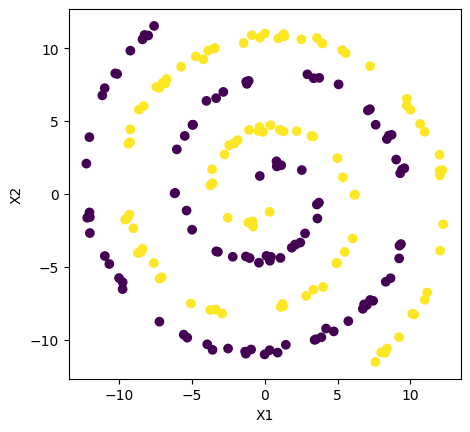

In [245]:
df = pd.read_csv(r'Data_2/data.csv')
X = df[['X1', 'X2']].values
y = df['y'].values

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X[:,0], X[:,1], c=y)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_aspect(1)


### Lösung

## b)

Trainieren Sie nun eine logistische Regression und einen MLPClassifier auf diesen Daten. Sie müssen die Daten nicht standardisieren, da die Werte bereits um 0 zentriert sind und dieselbe Größenordnung haben. Sie müssen die Daten auch nicht in ein Trainings- und Testset aufteilen, da wir Ihnen ein separates Testset zur Verfügung stellen. 

Berechnen Sie die Accuracy der logistischen Regression und des MLPClassifiers auf den Trainingsdaten. 

In [246]:
# Trainieren Sie hier die logistische Regression
lr = LogisticRegression() # Erstellen des Modells
lr.fit(X, y)
lr_pred = lr.predict(X)
lr_acc = accuracy_score(y, lr_pred)
print("Logistische Regression Accuracy: ", lr_acc)

Logistische Regression Accuracy:  0.58


In [247]:
# Trainieren Sie hier den MLP Classifier
mlp = MLPClassifier(hidden_layer_sizes=((32,32, 32, 32, 16)), max_iter=50000, random_state=0)
mlp.fit(X, y)
mlp_pred = mlp.predict(X)
mlp_acc = accuracy_score(y, mlp_pred)
print("MLP Classifier Accuracy: ", mlp_acc)

MLP Classifier Accuracy:  1.0


## c)

Verwenden Sie Pandas, um den Datensatz `X_test.csv` in einem Dataframe `df` zu laden.

Der Datensatz enthält nun die Koordinaten der Punkte ohne ihre Zuordnung. Verwenden Sie das trainierte Netzwerk um die Punkte den Spiralarmen zuzuordnen, und plotten Sie das Resultat sowohl für die Logistische Regression als auch für den MLPClassifier.

Verstehen Sie nun, weshalb die logistische Regression so schlecht abschneidet? 

/Users/std_admin/Desktop/system/ETH/Bachelor Physics/ETH-Data-Analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/Users/std_admin/Desktop/system/ETH/Bachelor Physics/ETH-Data-Analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Text(0, 0.5, 'X2')

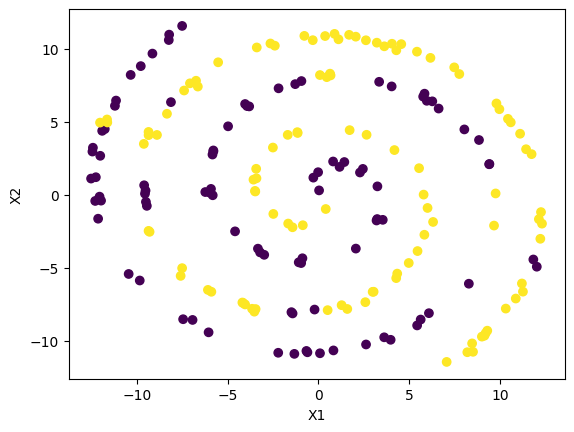

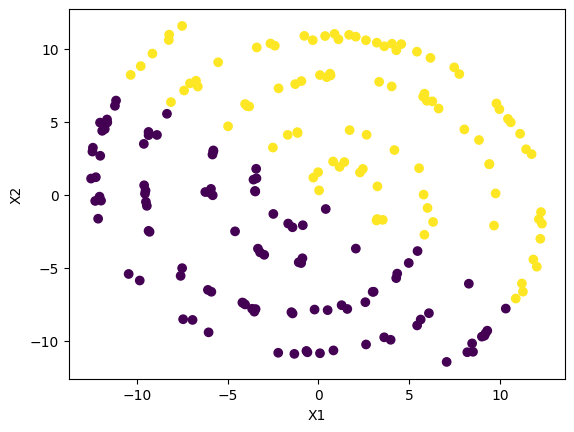

In [248]:
X_test = pd.read_csv(r'Data_2/X_test.csv')
y_test = mlp.predict(X_test)

fig = plt.figure()
plt.scatter(X_test['X1'], X_test['X2'], c=y_test)

plt.xlabel('X1')
plt.ylabel('X2')

y_test = lr.predict(X_test)

fig = plt.figure()
plt.scatter(X_test['X1'], X_test['X2'], c=y_test)

plt.xlabel('X1')
plt.ylabel('X2')

# Aufgabe 3: Propagation durch ein neuronales Netz

In der letzten Aufgabe sollen Sie die Propagation durch die hidden Layers eines neuronalen Netzes selber implementieren. In jedem Layer nimmt jedes der $M$ Neuronen die $N$ Inputs, multipliziert jeden davon mit einem Gewicht und bildet dann die Summe. Dies entspricht einer linearen Abbildung eines $N$-Dimensionalen Inputvektors auf $M$ Neuronen, was wiederum als Multiplikation des Inputvektors mit einer $(M\times N)$-Matrix aufgefasst werden kann. In jedem Neuron wird dann zu der Summe noch ein Offset oder Bias addiert und dann wird eine nichtlineare Aktivierungsfunktion darauf angewendet. Diese $M$ Zahlen sind der Output dieses Layers, der als Input an das nächste Layer übergeben wird. 

## a)

Schreiben Sie zuerst zwei Funktionen, die ein einzelnes hidden Layer mit einer ReLU- bzw. einer Sigmoid-Aktivierungsfunktion implementieren. Die Argumente der Funktion sind:

- $N$-dimensionaler Inputvektor (1D-Array mit N Einträgen)
- $(M\times N)$-Gewichtsmatrix ($N$ Gewichte für jedes der $M$ Neuronen)
- $M$-dimensionaler Biasvektor (ein Biaswert für jedes der $M$ Neuronen)

Der Rückgabewert ist ein $M$-dimensionaler Vektor mit den Outputs aller Neuronen.

Für die Matrixmultiplikation  können Sie `np.dot` oder `@` verwenden.

In [249]:
# Ihr Code
def forward_propagation(weight_matrix, bias_vector, input_vector):
    z = np.dot(weight_matrix, input_vector)
    z += bias_vector
    return np.maximum(0, z)

def forward_sigmoid(weight_matrix, bias_vector, input_vector):
    z = np.dot(weight_matrix, input_vector)
    z += bias_vector
    return 1 / (1 + np.exp(-z))

## b)

Nutzen Sie das im nächsten Abschnitt gegebene Testarray zusammen mit der gegebenen Gewichtsmatrix und des Biasvektors um ihre Funktionen zu überprüfen. Vergleichen Sie Ihre ergebnisse mit den Resultaten, die wir Ihnen zur Verfügung stellen.

In [250]:
testarray = np.arange(1, 5)

weight = np.ones((3, 4))
bias = np.array([0, -10, -12])

result_ReLU = np.array([10, 0, 0])
result_sigmoid = np.array([0.9999546, 0.5, 0.11920292])

print(forward_propagation(weight, bias, testarray))
print(forward_sigmoid(weight, bias, testarray))

[10.  0.  0.]
[0.9999546  0.5        0.11920292]


## c) 

Schreiben Sie nun eine Funktion, die die Funktionen aus a) zu einem Netzwerk zusammenfügt. Die Inputs sind:

- input_vector: 1D-Array mit den Inputs für das erste Layer.
- weights: eine Liste mit k-Einträgen, wobei k die Anzahl hidden Layers ist. Jeder Eintrag enthält die Gewichtsmatrix für das entsprechende Layer.
- biases: eine Liste mit k-Einträgen. Jeder Eintrag enthält den Biasvektor für das entsprechende Layer.

Die Funktion iteriert durch alle Layers und propagiert immer den Output des vorigen Layers durch das nächste Layer. Verwenden Sie für alle Layers ausser dem allerletzten die ReLU-Aktivierungsfunktion. Für das letzte Layer verwenden Sie die Sigmoid-Aktivierungsfunktion.

Für einen Classifier will man einen binären Output, 0 oder 1. Da die Sigmoid-Aktivierungsfunktion auch Werte zwischen 0 und 1 zurückgibt, müssen Sie diese noch mit `np.round` auf 0 oder 1 runden.

*Bemerkung: Die Argumente `weights` und `biases` müssen python-Listen anstelle von Numpy-Arrays sein, da diese Einträge unterschiedlichen Typs haben können, z.B.:*
```python
liste = ['a', 2, np.array([2, 5])]
```

In [251]:
def forward_propagation_network(weights, biases, input_vector):
    output = input_vector
    
    n = len(weights)
    for i in range(n):
        if i < n - 1:
            output = forward_propagation(weights[i], biases[i], output)
        else:
            output = forward_sigmoid(weights[i], biases[i], output)
    return np.round(output)

## d)

Mit der Funktion in b) haben sie schon die `predict`-Funktion für einen NN-Classifier implementiert! Das Trainieren des Netzwerks, also das Optimieren der Gewichtsmatrizen und Biasvektoren, ist deutlich aufwendiger und übersteigt den Umfang dieser Übung.

Allerdings können wir unsere Implementation auf Klassifizierungsprobleme anwenden, wenn wir das Resultat des Trainings, also die Gewichtsmatrizen und Biasvektoren, kennen.

Der Datensatz `Data_3/data.csv` enthält ähnlich zu Aufgabe 2 zwei Spalten, die den x- und y-Koordinaten von Punkten entsprechen. Die Punkte können in einen inneren Kreis und einen äusseren Ring aufgeteilt werden.

Laden Sie den Datensatz in eine Dataframe und plotten Sie die Punkte auf einem Scatterplot. 

Text(0, 0.5, 'X2')

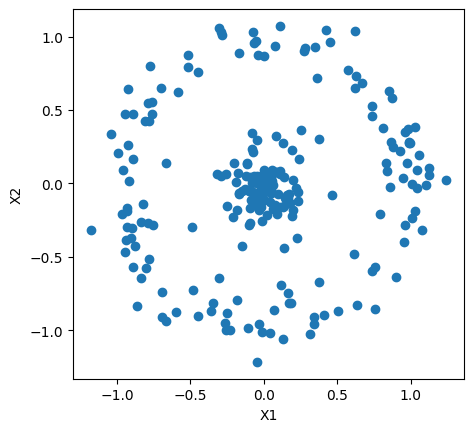

In [252]:
df = pd.read_csv(r'Data_3/data.csv')
X = df[['X1', 'X2']].values

fig  = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.scatter(X[:, 0], X[:,1])
ax.set_aspect(1)

ax.set_xlabel('X1')
ax.set_ylabel('X2')

## e)

Benutzen Sie nun Ihre Funktion mit den bereitgestellten Gewichtsmatrizen und Biasvektoren, um für jeden Punkt eine Vorhersage zu treffen, ob er in der inneren oder der äusseren Menge liegt. 

Analog zur Spirale können Sie das Resultat in einem Scatterplot darstellen und die Vorhersage als Farbwert übergeben.

In [ ]:
weights = pickle.load(open('Data_3/weights.p', 'rb'))
biases = pickle.load(open('Data_3/biases.p', 'rb'))

predictions = np.zeros(len(X[:, 0]))

# Iteration durch alle (X1, X2) paare.
for i in range(len(X[:, 0])):
    # Voraussage
    predictions[i] = forward_propagation_network(weights, biases, [X[i, 0], X[i, 1]])
    
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X[:, 0], X[:, 1], c=predictions)
ax.set_aspect(1)

ax.set_xlabel('X1')
ax.set_ylabel('X2')

NameError: name 'weights' is not defined